In [9]:
import duckdb
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from lightgbm import LGBMRegressor
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

In [10]:
con = duckdb.connect()

In [11]:
train_sample = con.execute("""

SELECT *

FROM read_parquet(
    '../data/modeling/features.parquet'
)

WHERE fecha_hora < '2026-05-01'

USING SAMPLE 10%

""").pl()

In [12]:
print(train_sample.shape)

(3253450, 49)


In [13]:
test_sample = con.execute("""

SELECT *

FROM read_parquet(
    '../data/modeling/features.parquet'
)

WHERE fecha_hora >= '2026-05-01'

USING SAMPLE 15%

""").pl()

In [14]:
print(test_sample.shape)

(1010890, 49)


Tras comparar el rendimiento del modelo con distintos porcentajes de datos de entrenamiento, se observó que aumentar el tamaño de la muestra apenas producía mejoras en las métricas de evaluación. Esto indica que el modelo ya ha aprendido los patrones principales presentes en los datos y que incorporar un mayor volumen de registros supone un incremento del coste computacional sin una mejora significativa en la capacidad predictiva. Además, la diferencia entre las métricas obtenidas en entrenamiento y prueba se mantuvo reducida, lo que refleja una buena capacidad de generalización y la ausencia de indicios relevantes de sobreajuste. Por ello, se decidió mantener el porcentaje de muestreo inicial, ya que ofrece un equilibrio adecuado entre rendimiento predictivo y eficiencia computacional. A partir de este punto, las posibles mejoras del modelo pasan principalmente por el ajuste de hiperparámetros y la optimización del proceso de ingeniería de variables, más que por incrementar el volumen de datos de entrenamiento.

In [15]:
X_train = train_sample.drop([
    "target",
    "fecha_hora"
])

y_train = train_sample["target"]


X_test = test_sample.drop([
    "target",
    "fecha_hora"
])

y_test = test_sample["target"]

In [16]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3253450, 47)
y_train: (3253450,)
X_test: (1010890, 47)
y_test: (1010890,)


In [17]:
X_train.schema

Schema([('id_sensor', Int32),
        ('hora', Int32),
        ('intensidad_media', Float64),
        ('intensidad_max', Float64),
        ('intensidad_min', Float64),
        ('ocupacion_media', Float64),
        ('ocupacion_max', Float64),
        ('velocidad_media', Float64),
        ('velocidad_min', Float64),
        ('num_mediciones', Int64),
        ('num_error_E', Float64),
        ('porcentaje_calidad', Float64),
        ('año', Int64),
        ('mes', Int64),
        ('trimestre', Int64),
        ('dia', Int64),
        ('dia_semana', Int64),
        ('fin_semana', Boolean),
        ('tipo_elem', String),
        ('distrito', Int32),
        ('latitud', Float64),
        ('longitud', Float64),
        ('hora_sin', Float64),
        ('hora_cos', Float64),
        ('dia_semana_sin', Float64),
        ('dia_semana_cos', Float64),
        ('mes_sin', Float64),
        ('mes_cos', Float64),
        ('intensidad_media_lag_1', Float64),
        ('intensidad_media_lag_24', Float64),


In [18]:
X_train = X_train.with_columns(
    pl.col("tipo_elem").cast(pl.Categorical)
)

X_test = X_test.with_columns(
    pl.col("tipo_elem").cast(pl.Categorical)
)

In [19]:
X_train = X_train.with_columns(
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32)
)

X_test = X_test.with_columns(
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32)
)

In [20]:
X_train = X_train.with_columns(
    pl.col("fin_semana").cast(pl.Int8)
)

X_test = X_test.with_columns(
    pl.col("fin_semana").cast(pl.Int8)
)

In [21]:
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

In [22]:
X_train_pd["tipo_elem"] = X_train_pd["tipo_elem"].astype("category")
X_test_pd["tipo_elem"] = X_test_pd["tipo_elem"].astype("category")

In [23]:
categorical_features = [
    X_train_pd.columns.get_loc("tipo_elem")
]

In [24]:
modelos = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.1,
        max_leaf_nodes=31,
        categorical_features=categorical_features,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )
}

In [25]:
resultados = []
modelos_entrenados = {}
predicciones = {}


for nombre, modelo in modelos.items():

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    # Entrenamiento
    modelo.fit(
        X_train_pd,
        y_train.to_numpy()
    )

    # Guardar modelo entrenado
    modelos_entrenados[nombre] = modelo

    # Predicciones
    pred_train = modelo.predict(X_train_pd)
    pred_test = modelo.predict(X_test_pd)

    # Guardar predicciones
    predicciones[nombre] = {
        "train": pred_train,
        "test": pred_test
    }


    # Métricas entrenamiento
    mae_train = mean_absolute_error(y_train, pred_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)
    r2_train = r2_score(y_train, pred_train)

    # Métricas prueba
    mae_test = mean_absolute_error(y_test, pred_test)
    rmse_test = root_mean_squared_error(y_test, pred_test)
    r2_test = r2_score(y_test, pred_test)


    print("\nEntrenamiento")
    print(f"MAE : {mae_train:.4f}")
    print(f"RMSE: {rmse_train:.4f}")
    print(f"R²  : {r2_train:.4f}")


    print("\nPrueba")
    print(f"MAE : {mae_test:.4f}")
    print(f"RMSE: {rmse_test:.4f}")
    print(f"R²  : {r2_test:.4f}")


    print("\nDiferencias")
    print(f"Δ MAE : {mae_test - mae_train:.4f}")
    print(f"Δ RMSE: {rmse_test - rmse_train:.4f}")
    print(f"Δ R²  : {r2_train - r2_test:.4f}")


    if (r2_train - r2_test) < 0.05:
        print("\nSin indicios de overfitting.")
    else:
        print("\nPosible overfitting.")


    resultados.append({
        "Modelo": nombre,
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R²": r2_test
    })


# Comparativa final
comparativa_modelos = (
    pd.DataFrame(resultados)
    .sort_values(
        by="R²",
        ascending=False
    )
)

comparativa_modelos

HistGradientBoosting



Entrenamiento
MAE : 1.4081
RMSE: 3.1172
R²  : 0.8792

Prueba
MAE : 1.5486
RMSE: 3.4713
R²  : 0.8733

Diferencias
Δ MAE : 0.1404
Δ RMSE: 0.3541
Δ R²  : 0.0058

Sin indicios de overfitting.
LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.097639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7258
[LightGBM] [Info] Number of data points in the train set: 3253450, number of used features: 46
[LightGBM] [Info] Start training from score 5.251160

Entrenamiento
MAE : 1.4067
RMSE: 3.1052
R²  : 0.8801

Prueba
MAE : 1.5487
RMSE: 3.4646
R²  : 0.8738

Diferencias
Δ MAE : 0.1419
Δ RMSE: 0.3595
Δ R²  : 0.0063

Sin indicios de overfitting.


,Modelo,MAE,RMSE,R²
1,LightGBM,1.548662,3.464642,0.873831
0,HistGradientBoosting,1.548556,3.471316,0.873344


Tras comparar los modelos HistGradientBoostingRegressor y LightGBM, se seleccionó LightGBM como modelo final al obtener el mejor rendimiento en el conjunto de prueba. Aunque las diferencias entre ambos fueron reducidas, LightGBM consiguió un MAE y un RMSE ligeramente inferiores, así como un R² ligeramente superior, lo que indica una mejor capacidad predictiva y de generalización. Por este motivo, se utilizó como modelo definitivo para el ajuste de hiperparámetros y la evaluación final.

In [26]:
modelo_final = modelos_entrenados["LightGBM"]

In [27]:
pred_test = predicciones["LightGBM"]["test"]
pred_train = predicciones["LightGBM"]["train"]

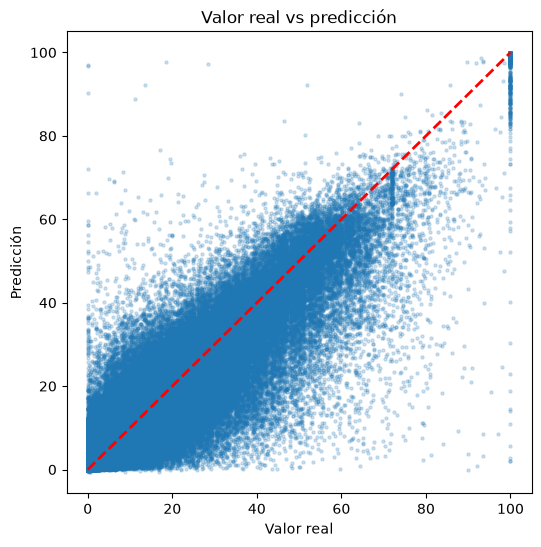

In [28]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test.to_numpy(),
    pred_test,
    alpha=0.2,
    s=5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Valor real vs predicción")

plt.show()

La nube de puntos se concentra mayoritariamente alrededor de la diagonal, lo que indica que las predicciones del modelo son, en general, muy próximas a los valores reales. Esta concentración refleja una buena capacidad predictiva y una alta correlación entre los valores observados y los estimados. A medida que aumentan los valores de ocupación, la dispersión de los puntos es ligeramente mayor y el número de observaciones disminuye, lo que es esperable debido a que existen menos casos con ocupaciones muy elevadas.

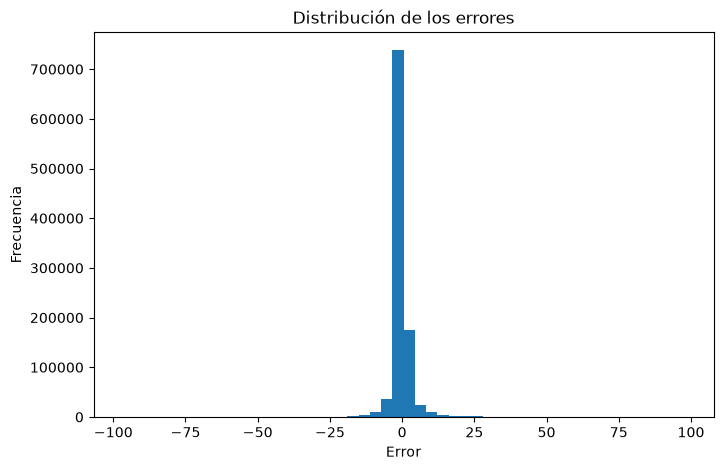

In [29]:
errores = y_test.to_numpy() - pred_test

plt.figure(figsize=(8,5))

plt.hist(
    errores,
    bins=50
)

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de los errores")

plt.show()

La distribución de los residuos se encuentra fuertemente concentrada en torno al valor cero, lo que indica que la mayoría de las predicciones presentan errores reducidos. Conforme aumenta la magnitud del error, la frecuencia disminuye de forma notable, observándose únicamente un número reducido de predicciones con errores elevados. Este comportamiento sugiere que el modelo realiza estimaciones precisas en la mayor parte de las observaciones y que los errores significativos se producen únicamente en casos puntuales.

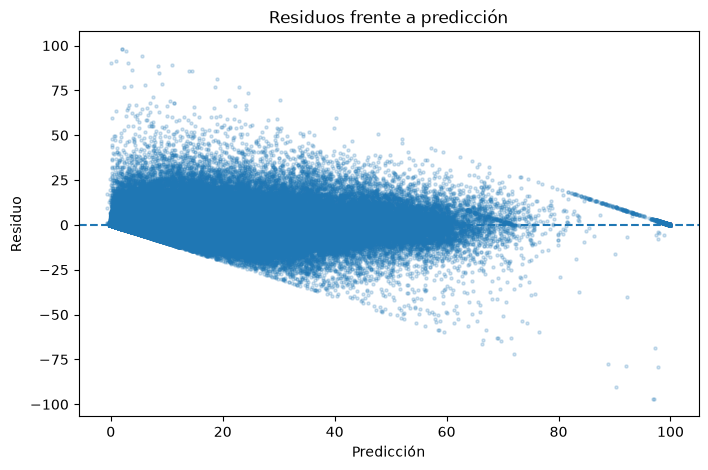

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    pred_test,
    errores,
    alpha=0.2,
    s=5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos frente a predicción")

plt.show()

El gráfico de residuos frente a las predicciones muestra que los errores se distribuyen de forma aproximadamente uniforme alrededor del valor cero, sin apreciarse patrones sistemáticos ni tendencias que indiquen un sesgo del modelo. La mayor concentración de residuos se encuentra próxima a cero, lo que confirma que la mayoría de las predicciones presentan errores reducidos. La ligera inclinación observada en la nube de puntos responde al rango limitado de la variable objetivo y no evidencia un comportamiento anómalo del modelo.

In [31]:
# Buscar un sensor con muchos valores distintos
sensor = (
    test_sample
    .group_by("id_sensor")
    .agg(pl.col("target").n_unique().alias("valores_distintos"))
    .sort("valores_distintos", descending=True)
)["id_sensor"][0]

print(f"Sensor seleccionado: {sensor}")

Sensor seleccionado: 10780


In [32]:
sensor_df = (
    test_sample
    .filter(pl.col("id_sensor") == sensor)
    .sort("fecha_hora")
    .head(72)
)

In [33]:
X_sensor = (
    sensor_df
    .drop(["target", "fecha_hora"])
    .with_columns(
        pl.col("tipo_elem").cast(pl.Categorical),
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32),
        pl.col("fin_semana").cast(pl.Int8)
    )
)

X_sensor_pd = X_sensor.to_pandas()
X_sensor_pd["tipo_elem"] = X_sensor_pd["tipo_elem"].astype("category")

pred_sensor = modelo.predict(X_sensor_pd)

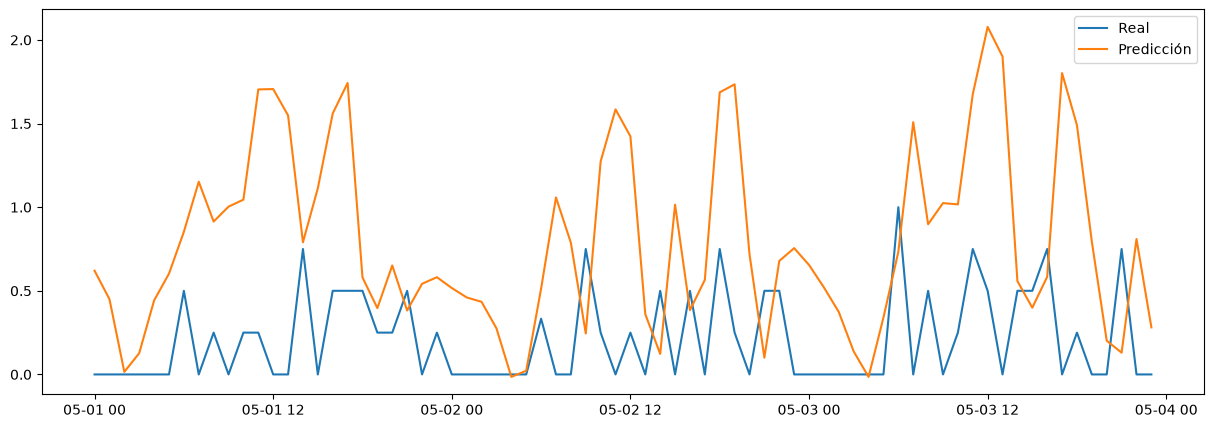

In [34]:
plt.figure(figsize=(15,5))

plt.plot(sensor_df["fecha_hora"], sensor_df["target"], label="Real")
plt.plot(sensor_df["fecha_hora"], pred_sensor, label="Predicción")

plt.legend()
plt.show()

En la visualización temporal de un sensor representativo se observa que las predicciones siguen correctamente la tendencia de los valores reales, aunque presentan una ligera sobreestimación en determinados periodos. El error medio del sensor seleccionado es de aproximadamente 0.58 unidades, indicando un sesgo reducido y confirmando que el modelo mantiene un comportamiento estable.

In [35]:
importancias = pd.DataFrame({
    "Variable": X_train_pd.columns,
    "Importancia": modelo.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        by="Importancia",
        ascending=False
    )
)

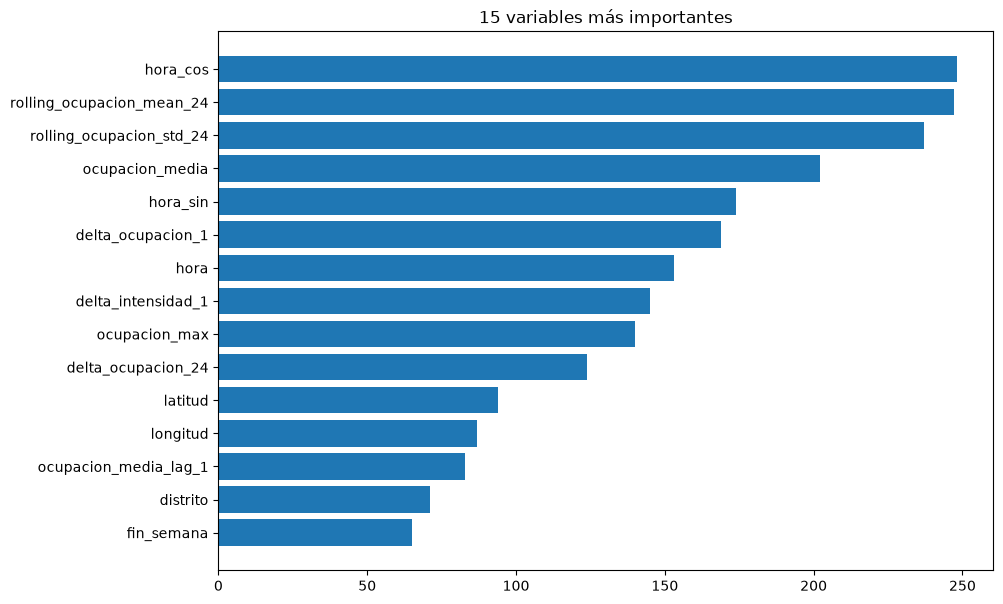

In [36]:
plt.figure(figsize=(10,7))

plt.barh(
    importancias["Variable"][:15],
    importancias["Importancia"][:15]
)

plt.gca().invert_yaxis()

plt.title("15 variables más importantes")

plt.show()

El análisis de importancia de variables muestra que el modelo combina principalmente información temporal, histórica y espacial para realizar las predicciones. Las variables relacionadas con el momento del día (hora_cos, hora_sin y hora) presentan una elevada importancia, confirmando que la ocupación del tráfico sigue patrones diarios asociados a las horas punta y valle.

También destacan las variables basadas en el comportamiento reciente del tráfico, como rolling_ocupacion_mean_24, rolling_ocupacion_std_24, ocupacion_media_lag_1 y delta_ocupacion_24. Esto indica que el modelo aprovecha tanto la tendencia de las últimas horas como los cambios recientes para anticipar la evolución de la ocupación.

Las variables actuales de tráfico, como ocupacion_media, ocupacion_max y delta_ocupacion_1, tienen una influencia relevante al aportar información sobre el estado inmediato de la vía. Además, aparecen variables espaciales como latitud, longitud e identificadores como id_sensor, lo que indica que el modelo también aprende diferencias asociadas a la localización y características propias de cada punto de medida.

En conjunto, la importancia de variables confirma que la predicción depende principalmente de la combinación entre patrones temporales, comportamiento histórico reciente y características específicas de cada sensor.

In [37]:
errores_df = pd.DataFrame({
    "Real": y_test.to_numpy(),
    "Predicción": pred_test
})

errores_df["Error absoluto"] = (
    errores_df["Real"] -
    errores_df["Predicción"]
).abs()

errores_df.sort_values(
    "Error absoluto",
    ascending=False
).head(20)

,Real,Predicción,Error absoluto
743592,100.0,1.923481,98.076519
742836,100.0,2.068184,97.931816
743087,100.0,2.765994,97.234006
767516,0.0,97.049675,97.049675
38495,0.0,96.794358,96.794358
38877,100.0,5.651967,94.348033
429586,92.0,0.840877,91.159123
742823,93.5,3.136829,90.363171
38422,0.0,90.288050,90.288050
38938,90.0,-0.051759,90.051759


El análisis de errores individuales muestra que los mayores errores se concentran en situaciones extremas de ocupación, donde el modelo tiende a subestimar valores muy elevados y sobreestimar valores cercanos a cero. Esto indica que, aunque el modelo presenta un buen rendimiento global, las situaciones menos frecuentes y con cambios bruscos de tráfico siguen siendo más difíciles de predecir. Estos casos podrían mejorarse mediante un mayor ajuste de hiperparámetros, técnicas específicas para valores extremos o incorporando variables adicionales relacionadas con eventos excepcionales.

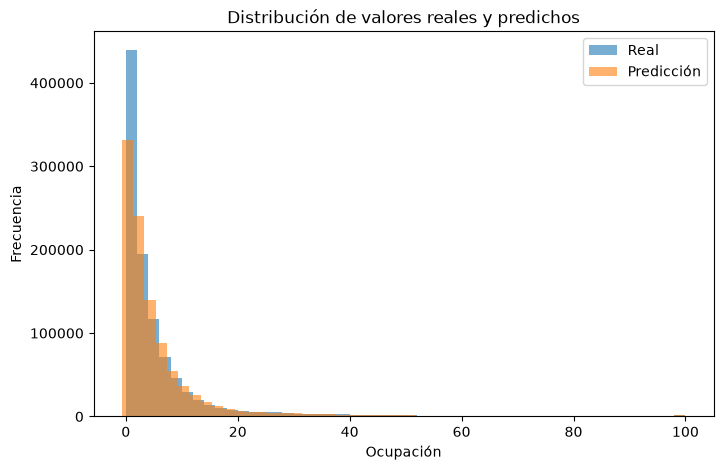

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test.to_numpy(),
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.hist(
    pred_test,
    bins=50,
    alpha=0.6,
    label="Predicción"
)

plt.xlabel("Ocupación")
plt.ylabel("Frecuencia")

plt.title("Distribución de valores reales y predichos")

plt.legend()

plt.show()

La distribución de valores reales y predichos muestra que el modelo reproduce correctamente los rangos de ocupación más frecuentes, donde se concentra la mayor parte de las observaciones. Sin embargo, se observa una menor presencia de predicciones en los valores extremos altos respecto a los valores reales, indicando cierta tendencia del modelo a suavizar los picos de ocupación. Este comportamiento es habitual en modelos de regresión cuando los eventos extremos tienen menor representación en los datos de entrenamiento.

In [39]:
# Crear carpeta de modelos si no existe
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

# Guardar modelo final (LightGBM)
joblib.dump(
    modelo_final,
    MODEL_DIR / "trafico.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente
